# VIX Mean Reversion — Signal Research

**Instrument:** SVXY (short volatility ETF)
**Signal:** Buy SVXY during VIX spikes, exit when volatility normalizes.
**Entry:** Next day's open after entry signal triggers.
**Exit:** VIX EMA7 declining AND VIX < entry VIX. Or stop loss (-20%). Max hold 200d.
**Direction:** Long-only on SVXY (economically: short vol).
**Data:** VIX from WRDS, SVXY from Alpaca.

**Parameter selection:** Hand-tuned to VIX dynamics. No grid search — too many
interacting parameters (regime thresholds, EMA periods, stochastic filter,
cooldown, immunity). Parameters are economically motivated:
- VIX spike detection (>18, >1.1x SMA40) captures mean-reversion opportunities
- Regime classification adapts entry strictness to VIX level
- EMA7/18 declining confirms VIX is rolling over before entry/exit
- Cooldown/immunity prevent whipsaw re-entries

**Academic backing:** VIX mean reversion is one of the strongest documented
effects in volatility markets. The variance risk premium (VRP) — the gap
between implied and realized vol — is persistently negative, creating a
structural tailwind for short-vol strategies. Documented in Carr & Wu (2009)
'Variance Risk Premiums' and Eraker (2009).

**Pre/post-2018:** SVXY changed from -1x to -0.5x after Volmageddon (Feb 2018).
Pre-2018 allocation is halved (47.5%) to equalize economic exposure.

**Sizing & implementation** -> see `VIX_Mean_Reversion_Implementation.ipynb`

## 1. Setup

In [17]:
import sys
sys.path.insert(0, "../..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from alpaca.data.timeframe import TimeFrame, TimeFrameUnit

from _shared.loaders_data import fetch_historical_data
from _shared.loaders_wrds import load_vix
from _shared.fees import calculate_fees, calculate_fees_pct
from _shared.implementations import build_daily_equity
from _shared.significance import full_significance_report, print_significance_report

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)


In [18]:
# =============================================================================
# CONFIGURATION
# =============================================================================

SYMBOL     = "SVXY"
START_FULL = "2011-10-01"   # SVXY launched Oct 2011
START_POST = "2018-03-01"   # Post-Volmageddon
END_DATE   = "2026-04-01"

STARTING_CAPITAL = 100_000
LEVERAGE         = 1
STRATEGY_NAME    = "VIX Mean Reversion"
SAVE_NAME        = "vix_mean_reversion"
BET_SIZE         = 0.85

# Leverage transition
VOLMAGEDDON_DATE       = pd.Timestamp("2018-02-27")
ALLOC_PRE_2018         = 0.475   # Half allocation when SVXY was -1x
ALLOC_POST_2018        = 0.95    # Full allocation when SVXY is -0.5x

# Spike detection
VIX_SPIKE_MIN   = 18
SMA_SPIKE       = 40
SPIKE_SMA_MULT  = 1.10

# Technical indicators
EMA_SHORT = 7;  EMA_LONG = 18
STOCH_K = 7;    STOCH_SMOOTH = 3;  STOCH_D = 3

# Regime thresholds
VIX_NORMAL_MAX  = 30;  VIX_30_MAX = 40;  VIX_AUTOBUY_MIN = 45

# Immunity & cooldown
IMMUNITY_NORMAL = 2;  IMMUNITY_VIX30 = 5;  IMMUNITY_VIX40 = 5
COOLDOWN_DAYS   = 2;  ENHANCED_DAYS  = 5

# Stop loss
STOP_LOSS_PCT = -0.20

# Volmageddon exclusion
VOLMAGEDDON_EXCLUSIONS = pd.to_datetime([
    "2018-02-05", "2018-02-06", "2018-02-07", "2018-02-08", "2018-02-09",
])

## 2. Data Fetching

In [19]:
# ── Fetch SVXY from Alpaca ──
data_dict = fetch_historical_data(
    [SYMBOL], TimeFrame(1, TimeFrameUnit.Day), START_FULL, END_DATE)

svxy = data_dict[SYMBOL].copy()
if svxy.index.tz is None:
    svxy.index = svxy.index.tz_localize("UTC").tz_convert("US/Eastern")
else:
    svxy.index = svxy.index.tz_convert("US/Eastern")
svxy = svxy.reset_index()
svxy["date"] = svxy["timestamp"].dt.date
svxy = svxy.groupby("date").last().reset_index()
svxy["date"] = pd.to_datetime(svxy["date"])

print(f"SVXY bars: {len(svxy):,}")
print(f"Date range: {svxy['date'].iloc[0].date()} -> {svxy['date'].iloc[-1].date()}")
print(f"Price range: ${svxy['close'].min():.2f} -> ${svxy['close'].max():.2f}")

# ── Daily prices for mark-to-market equity curve ──
d = data_dict[SYMBOL].reset_index()
d["date"] = pd.to_datetime(d["timestamp"]).dt.tz_localize(None).dt.normalize()
daily_prices = d.set_index("date")["close"]
print(f"Daily prices for mark-to-market: {len(daily_prices)} bars")


Fetching SVXY...
  2,575 bars
SVXY bars: 2,575
Date range: 2016-01-04 -> 2026-03-31
Price range: $13.14 -> $276.42
Daily prices for mark-to-market: 2575 bars


In [20]:
# ── Load VIX from WRDS ──
WRDS_DATA_DIR = "../../data/wrds"
vix_raw = load_vix(start_date=START_FULL, end_date=END_DATE, data_dir=WRDS_DATA_DIR)
vix = vix_raw[["date", "vix", "vixo", "vixh", "vixl"]].copy()
vix = vix.dropna(subset=["vix"]).reset_index(drop=True)

# ── Merge ──
df = svxy.merge(vix, on="date", how="inner", suffixes=("", "_vix"))
df = df.sort_values("date").reset_index(drop=True)
df["is_pre_2018"] = df["date"] < VOLMAGEDDON_DATE

print(f"Merged bars: {len(df):,}")
print(f"Date range: {df['date'].iloc[0].date()} -> {df['date'].iloc[-1].date()}")
print(f"Pre-2018: {df['is_pre_2018'].sum()} days, Post-2018: {(~df['is_pre_2018']).sum()} days")

Loaded 15_cboe_vix.parquet: 10,678 rows x 17 cols
Merged bars: 2,575
Date range: 2016-01-04 -> 2026-03-31
Pre-2018: 541 days, Post-2018: 2034 days


## 3. Technical Indicators

In [21]:
# EMAs on VIX highs
df["vix_ema7"] = df["vixh"].ewm(span=EMA_SHORT, adjust=False).mean()
df["vix_ema18"] = df["vixh"].ewm(span=EMA_LONG, adjust=False).mean()

# SMA40
df["vix_sma40"] = df["vix"].rolling(window=SMA_SPIKE).mean()

# Stochastic
vix_low_min = df["vixl"].rolling(window=STOCH_K).min()
vix_high_max = df["vixh"].rolling(window=STOCH_K).max()
raw_k = 100 * (df["vix"] - vix_low_min) / (vix_high_max - vix_low_min)
df["stoch_k"] = raw_k.rolling(window=STOCH_SMOOTH).mean()
df["stoch_d"] = df["stoch_k"].rolling(window=STOCH_D).mean()

# Trends
df["ema7_declining"] = df["vix_ema7"] < df["vix_ema7"].shift(1)
df["ema18_declining"] = df["vix_ema18"] < df["vix_ema18"].shift(1)

# Spike detection
df["vix_spike"] = (df["vix"] >= VIX_SPIKE_MIN) & (df["vix"] > df["vix_sma40"] * SPIKE_SMA_MULT)

# Volmageddon exclusion
df["is_volmageddon"] = df["date"].isin(VOLMAGEDDON_EXCLUSIONS)

print(f"Spike days: {df['vix_spike'].sum()} / {len(df)} ({df['vix_spike'].mean()*100:.1f}%)")
print(f"VIX > 30: {(df['vix'] >= 30).sum()} days")
print(f"VIX > 45: {(df['vix'] >= 45).sum()} days")

Spike days: 427 / 2575 (16.8%)
VIX > 30: 154 days
VIX > 45: 26 days


## 4. Signal Engine

Generates raw trades with standardized columns.
**Entry:** Next day's open after entry conditions are met.
**Exit:** Signal exit (EMA7 declining + VIX < entry VIX), stop loss, or max hold.

Entry/exit logic, regime classification, immunity, and cooldown are
preserved exactly from the original notebook.

In [22]:
def classify_regime(vix_level):
    if vix_level >= VIX_AUTOBUY_MIN: return "autobuy"
    elif vix_level >= VIX_30_MAX:    return "vix40"
    elif vix_level >= VIX_NORMAL_MAX: return "vix30"
    return "normal"

def check_entry(row, in_cooldown, in_enhanced):
    if row["is_volmageddon"] or in_cooldown:
        return False, None
    vix = row["vix"]
    spike = row["vix_spike"]
    ema7_dec = row["ema7_declining"]
    stoch_d_lt_k = row["stoch_d"] < row["stoch_k"]
    regime = classify_regime(vix)
    if in_enhanced and not (ema7_dec and stoch_d_lt_k):
        return False, None
    if regime == "autobuy":              return True, "autobuy"
    elif regime == "vix40" and spike and ema7_dec: return True, "vix40"
    elif regime == "vix30" and spike and ema7_dec: return True, "vix30"
    elif regime == "normal" and spike:    return True, "normal"
    return False, None

def get_immunity(regime):
    if regime == "normal": return IMMUNITY_NORMAL
    elif regime in ("vix30", "vix40"): return IMMUNITY_VIX30
    return 0


def generate_signals(df, stop_loss=None):
    """
    Generate raw VIX mean reversion trades — signal only, no sizing.
    Entry: next day's open after entry conditions met.
    Exit: EMA7 declining + VIX < entry VIX, or stop loss, or max hold (200d).
    """
    trades = []
    in_position = False
    entry_price = entry_vix = 0
    entry_time = entry_regime = None
    days_held = immunity = 0
    cooldown = enhanced = 0
    signal_day_idx = None

    for i in range(SMA_SPIKE, len(df)):
        row = df.iloc[i]

        if in_position:
            days_held += 1
            if immunity > 0:
                immunity -= 1
                continue

            # Stop loss
            if stop_loss is not None:
                pnl_pct = (row["close"] - entry_price) / entry_price
                if pnl_pct <= stop_loss:
                    exit_price = entry_price * (1 + stop_loss)
                    pct_return_gross = stop_loss
                    trades.append({
                        "entry_time": entry_time, "exit_time": row["date"],
                        "direction": "long", "instrument": SYMBOL,
                        "entry_price": round(entry_price, 4),
                        "exit_price": round(exit_price, 4),
                        "pct_return_gross": round(pct_return_gross, 6),
                        "exit_reason": "stop_loss",
                        "stop_price": round(entry_price * (1 + stop_loss), 4) if stop_loss else np.nan,
                    })
                    in_position = False
                    cooldown = COOLDOWN_DAYS
                    enhanced = ENHANCED_DAYS
                    continue

            # Signal exit
            if row["ema7_declining"] and row["vix"] < entry_vix:
                exit_price = row["close"]
                pct_return_gross = (exit_price - entry_price) / entry_price
                trades.append({
                    "entry_time": entry_time, "exit_time": row["date"],
                    "direction": "long", "instrument": SYMBOL,
                    "entry_price": round(entry_price, 4),
                    "exit_price": round(exit_price, 4),
                    "pct_return_gross": round(pct_return_gross, 6),
                    "exit_reason": "signal",
                    "stop_price": round(entry_price * (1 + stop_loss), 4) if stop_loss else np.nan,
                })
                in_position = False
                cooldown = COOLDOWN_DAYS
                enhanced = ENHANCED_DAYS
                continue

            # Max hold
            if days_held > 200:
                exit_price = row["close"]
                pct_return_gross = (exit_price - entry_price) / entry_price
                trades.append({
                    "entry_time": entry_time, "exit_time": row["date"],
                    "direction": "long", "instrument": SYMBOL,
                    "entry_price": round(entry_price, 4),
                    "exit_price": round(exit_price, 4),
                    "pct_return_gross": round(pct_return_gross, 6),
                    "exit_reason": "max_hold",
                    "stop_price": round(entry_price * (1 + stop_loss), 4) if stop_loss else np.nan,
                })
                in_position = False
                cooldown = COOLDOWN_DAYS
                enhanced = ENHANCED_DAYS

        else:
            if cooldown > 0:
                cooldown -= 1
                continue
            in_enh = enhanced > 0
            if enhanced > 0:
                enhanced -= 1

            ok, regime = check_entry(row, False, in_enh)
            if ok:
                # Entry at NEXT day's open
                if i + 1 < len(df):
                    next_row = df.iloc[i + 1]
                    entry_price = next_row["open"]
                    entry_vix = row["vix"]
                    entry_time = next_row["date"]
                    entry_regime = regime
                    in_position = True
                    days_held = 0
                    immunity = get_immunity(regime)

    # Close open position
    if in_position:
        row = df.iloc[-1]
        exit_price = row["close"]
        pct_return_gross = (exit_price - entry_price) / entry_price
        trades.append({
            "entry_time": entry_time, "exit_time": row["date"],
            "direction": "long", "instrument": SYMBOL,
            "entry_price": round(entry_price, 4),
            "exit_price": round(exit_price, 4),
            "pct_return_gross": round(pct_return_gross, 6),
            "exit_reason": "end_of_data",
            "stop_price": round(entry_price * (1 + stop_loss), 4) if stop_loss else np.nan,
        })

    if not trades:
        return pd.DataFrame()
    out = pd.DataFrame(trades)
    out["entry_time"] = pd.to_datetime(out["entry_time"])
    out["exit_time"] = pd.to_datetime(out["exit_time"])
    return out.sort_values("exit_time").reset_index(drop=True)

## 5. Signal Generation, Daily Equity & Significance Tests

Builds mark-to-market daily equity curve using `build_daily_equity` with
actual share counts. Significance tests run on real daily returns —
bootstrap Sharpe CI reflects the true annualized Sharpe, not the inflated
per-trade version.

In [23]:
raw_trades = generate_signals(df, stop_loss=STOP_LOSS_PCT)
print(f"Total signal trades: {len(raw_trades)}")
print(f"Avg hold: {(raw_trades['exit_time'] - raw_trades['entry_time']).dt.days.mean():.1f} days")
print(f"Has stop_price: {raw_trades['stop_price'].notna().sum()} / {len(raw_trades)}")

raw_trades["fee_pct"] = raw_trades.apply(
    lambda t: calculate_fees_pct(t["entry_price"], t["exit_price"], t["direction"]), axis=1)
raw_trades["pct_return_net"] = raw_trades["pct_return_gross"] - raw_trades["fee_pct"]

print(f"\nAvg fee: {raw_trades['fee_pct'].mean()*100:.4f}% per trade")
print(f"Avg gross return: {raw_trades['pct_return_gross'].mean()*100:.4f}%")
print(f"Avg net return: {raw_trades['pct_return_net'].mean()*100:.4f}%")

# ── Build mark-to-market daily equity for real Sharpe ──
# Simple bet sizing (85%) to get share counts
equity = STARTING_CAPITAL
shares_list = []
equity_curve = [STARTING_CAPITAL]
for _, t in raw_trades.iterrows():
    if equity <= 0:
        shares_list.append(0)
        equity_curve.append(equity)
        continue
    shares = int(equity * BET_SIZE / t["entry_price"])
    shares_list.append(shares)
    pnl = shares * (t["exit_price"] - t["entry_price"])
    fees = calculate_fees(shares, t["entry_price"], t["exit_price"], t["direction"])
    equity += pnl - fees
    equity_curve.append(equity)

trades_with_shares = raw_trades.copy()
trades_with_shares["shares"] = shares_list

daily_eq = build_daily_equity(
    trades_with_shares, equity_curve, STARTING_CAPITAL,
    daily_prices=daily_prices)

daily_returns = daily_eq.pct_change().dropna()
real_sharpe = daily_returns.mean() / daily_returns.std() * np.sqrt(252) if daily_returns.std() > 0 else 0
print(f"\nDaily-returns annualized Sharpe: {real_sharpe:.2f}")

# ── Significance tests on daily returns (real Sharpe, real bootstrap CI) ──
sig_daily = pd.DataFrame({
    "net_pnl": daily_returns.values,
    "equity_before": 1.0,
    "position": "long",
    "direction": "long",
})
if len(sig_daily) >= 30:
    report_gross = full_significance_report(sig_daily, strategy_name=f"{STRATEGY_NAME}")
    print_significance_report(report_gross)
    report_net = report_gross  # same curve includes fees


Total signal trades: 72
Avg hold: 5.5 days
Has stop_price: 72 / 72

Avg fee: 0.0731% per trade
Avg gross return: 2.9501%
Avg net return: 2.8770%

Daily-returns annualized Sharpe: 1.20

STATISTICAL SIGNIFICANCE — VIX Mean Reversion

1. t-test (returns > 0)
   Mean return:  0.0695% per trade
   t-statistic:  3.834
   p-value:      6.5e-05
   Significant:  YES

2. Bootstrap Sharpe (95% CI)
   Observed Sharpe:   1.2043
   95% CI:            [0.5859, 1.8031]
   % below zero:      0.01%
   Significant:       YES

3. Permutation test (random signs)
   Observed Sharpe:   1.2043
   p-value:           0.0
   Significant:       YES

──────────────────────────────────────────────────────────────────────
VERDICT: SIGNIFICANT (strong) (3/3 tests pass)


## 6. Mark-to-Market Daily Equity Curve

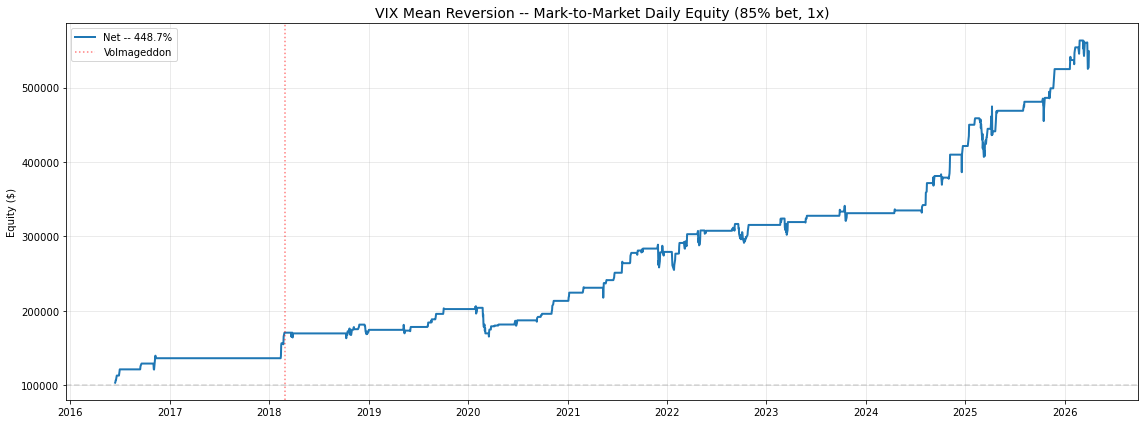

Final equity: $548,678
Total return: 448.7%
Max drawdown: -19.8%


In [24]:
# Plot the mark-to-market daily equity curve
fig, ax = plt.subplots(figsize=(16, 6))
ax.plot(daily_eq.index.to_numpy(), daily_eq.values, linewidth=2, color="C0",
        label=f"Net -- {(daily_eq.iloc[-1]/STARTING_CAPITAL-1)*100:.1f}%")
ax.axhline(STARTING_CAPITAL, color="gray", linestyle="--", alpha=0.3)
ax.axvline(VOLMAGEDDON_DATE, color="red", linestyle=":", alpha=0.5, label="Volmageddon")
ax.set_title(f"{STRATEGY_NAME} -- Mark-to-Market Daily Equity ({BET_SIZE:.0%} bet, {LEVERAGE}x)", fontsize=14)
ax.legend(); ax.grid(True, alpha=0.3); ax.set_ylabel("Equity ($)")
plt.tight_layout(); plt.show()

print(f"Final equity: ${daily_eq.iloc[-1]:,.0f}")
print(f"Total return: {(daily_eq.iloc[-1]/STARTING_CAPITAL-1)*100:.1f}%")
peak = daily_eq.expanding().max()
max_dd = ((daily_eq - peak) / peak).min() * 100
print(f"Max drawdown: {max_dd:.1f}%")


## 7. Exit Reason & Regime Analysis

In [25]:
print("EXIT REASON ANALYSIS")
print("=" * 60)
for reason in raw_trades["exit_reason"].unique():
    s = raw_trades[raw_trades["exit_reason"] == reason]
    avg_ret = s["pct_return_gross"].mean() * 100
    avg_hold = (s["exit_time"] - s["entry_time"]).dt.days.mean()
    wins = (s["pct_return_gross"] > 0).sum()
    print(f"  {reason:<15} n={len(s):3d}, WR={wins/len(s)*100:.0f}%, "
          f"avg return: {avg_ret:+.2f}%, avg hold: {avg_hold:.0f}d")

# Pre vs Post 2018
print("\n" + "=" * 60)
print("PRE vs POST 2018")
print("=" * 60)
for label, mask in [("Pre-2018", raw_trades["entry_time"] < VOLMAGEDDON_DATE),
                     ("Post-2018", raw_trades["entry_time"] >= VOLMAGEDDON_DATE)]:
    s = raw_trades[mask]
    if s.empty: continue
    n = len(s)
    wins = (s["pct_return_gross"] > 0).sum()
    avg_ret = s["pct_return_gross"].mean() * 100
    total_ret = ((1 + s["pct_return_gross"]).prod() - 1) * 100
    print(f"  {label}: {n} trades, WR={wins/n*100:.0f}%, Avg={avg_ret:+.2f}%, Total={total_ret:+.1f}%")

EXIT REASON ANALYSIS
  signal          n= 70, WR=81%, avg return: +3.36%, avg hold: 5d
  stop_loss       n=  1, WR=0%, avg return: -20.00%, avg hold: 9d
  end_of_data     n=  1, WR=0%, avg return: -2.51%, avg hold: 6d

PRE vs POST 2018
  Pre-2018: 6 trades, WR=100%, Avg=+11.04%, Total=+86.7%
  Post-2018: 66 trades, WR=77%, Avg=+2.21%, Total=+300.9%


## 8. Save Standardized Trades

In [26]:
import os, json

os.makedirs("results", exist_ok=True)

std_cols = ["entry_time", "exit_time", "direction", "instrument",
            "entry_price", "exit_price", "pct_return_gross", "exit_reason", "stop_price"]
raw_trades[std_cols].to_csv(f"results/{SAVE_NAME}_trades.csv", index=False)
print(f"Saved {len(raw_trades)} trades -> results/{SAVE_NAME}_trades.csv")

summary = {
    "strategy": STRATEGY_NAME, "instrument": SYMBOL,
    "portfolio": "long_term",
    "period": f"{START_FULL} -> {END_DATE}",
    "params": {"stop_loss": STOP_LOSS_PCT, "vix_spike_min": VIX_SPIKE_MIN,
               "sma_spike": SMA_SPIKE, "spike_sma_mult": SPIKE_SMA_MULT},
    "param_source": "Hand-tuned to VIX dynamics. VRP literature: Carr & Wu (2009).",
    "trades": len(raw_trades),
    "has_stop": True,
    "significance": {
        "gross": {"sharpe": report_gross["bootstrap"]["observed_sharpe"],
                  "verdict": report_gross["verdict"], "tests_passed": report_gross["tests_passed"]},
        "net":   {"sharpe": report_net["bootstrap"]["observed_sharpe"],
                  "verdict": report_net["verdict"], "tests_passed": report_net["tests_passed"]},
    },
}
with open(f"results/{SAVE_NAME}_summary.json", "w") as f:
    json.dump(summary, f, indent=2, default=str)
print(f"Saved summary -> results/{SAVE_NAME}_summary.json")
print(f"\nNext: run VIX_Mean_Reversion_Implementation.ipynb")

Saved 72 trades -> results/vix_mean_reversion_trades.csv
Saved summary -> results/vix_mean_reversion_summary.json

Next: run VIX_Mean_Reversion_Implementation.ipynb
